In [1]:
# Handling survival analysis or right-censored data in Numpyro

import pandas as pd

import jax
from jax import numpy as jnp, random

import numpyro
from numpyro import distributions as dist
from numpyro.distributions import (
    IntervalCensoredDistribution,
    LeftCensoredDistribution,
    RightCensoredDistribution,
    TruncatedDistribution
)
from numpyro.infer.hmc import NUTS
from numpyro.infer.mcmc import MCMC

import matplotlib.pyplot as plt

numpyro.set_host_device_count(4)

## parameter retrieval simulations

### right-censored data, real support

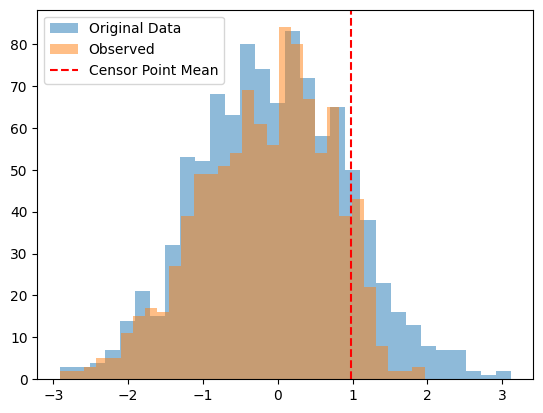

  0%|          | 0/3000 [00:00<?, ?it/s]

  0%|          | 0/3000 [00:00<?, ?it/s]

  0%|          | 0/3000 [00:00<?, ?it/s]

  0%|          | 0/3000 [00:00<?, ?it/s]

  0%|          | 0/3000 [00:00<?, ?it/s]

  0%|          | 0/3000 [00:00<?, ?it/s]

  0%|          | 0/3000 [00:00<?, ?it/s]

  0%|          | 0/3000 [00:00<?, ?it/s]

Naive model:

                mean       std    median      5.0%     95.0%     n_eff     r_hat
        mu     -0.16      0.03     -0.17     -0.21     -0.12   6671.64      1.00
     sigma      0.86      0.02      0.86      0.83      0.89   7726.46      1.00

Number of divergences: 0
None
Censored model:

                mean       std    median      5.0%     95.0%     n_eff     r_hat
        mu     -0.06      0.03     -0.06     -0.11     -0.01   6414.22      1.00
     sigma      0.99      0.03      0.99      0.95      1.03   7165.98      1.00

Number of divergences: 0
None


In [2]:
## simulate some data for parameter retrieval
rng_key = random.PRNGKey(0)
key_x, key_censor = random.split(rng_key)
n = 1000

x_orig = dist.Normal(0, 1).sample(key_x, (n,))
censor_point = dist.Normal(1, 0.5).sample(key_censor, (n,))
is_censored = x_orig > censor_point
x_observed = jnp.where(is_censored, censor_point, x_orig)

# plot histogram of x_orig and x_observed
plt.hist(x_orig, bins=30, alpha=0.5, label='Original Data')
plt.hist(x_observed, bins=30, alpha=0.5, label='Observed')
plt.axvline(censor_point.mean(), color='r', linestyle='--', label='Censor Point Mean')
plt.legend()
plt.show()



def model_naive(x):
    mu = numpyro.sample("mu", dist.Normal(0, 10))
    sigma = numpyro.sample("sigma", dist.HalfCauchy(5))
    with numpyro.plate("data", x.shape[0]):
        numpyro.sample("obs", dist.Normal(mu, sigma), obs=x)

def model_censored(x, censored):
    mu = numpyro.sample("mu", dist.Normal(0, 10))
    sigma = numpyro.sample("sigma", dist.HalfCauchy(5))
    with numpyro.plate("data", x.shape[0]):
        base_dist = dist.Normal(mu, sigma)
        censored_dist = RightCensoredDistribution(base_dist, censored=censored)
        numpyro.sample("obs", censored_dist, obs=x)

mcmc_naive = MCMC(NUTS(model_naive), num_warmup=1000, num_samples=2000, num_chains=4)
mcmc_naive.run(rng_key, x_observed)
mcmc_censored = MCMC(NUTS(model_censored), num_warmup=1000, num_samples=2000, num_chains=4)
mcmc_censored.run(rng_key, x_observed, is_censored)
print("Naive model:")
print(mcmc_naive.print_summary())
print("Censored model:")
print(mcmc_censored.print_summary())





## Interval censored data example, real support

In [3]:
rng_key = random.PRNGKey(1)

kx, kl, kr = random.split(rng_key, 3)
x_orig = dist.Normal(0,1).sample(kx, (1000,))
left = dist.Normal(-1, 0.5).sample(kl, (1000,))  # left censoring
right = dist.Normal(1.5, .25).sample(kr, (1000,))  # right censoring
cens_dist = IntervalCensoredDistribution(dist.Normal(0, 1))

min_val = -jnp.inf
max_val = jnp.inf

x1 = jnp.full(x_orig.shape, min_val)  # initialize with min
x2 = jnp.full(x_orig.shape, max_val)

x1 = jnp.where(x_orig > right, right, x1)  # right censored
x2 = jnp.where(x_orig < left, left, x2)  # left censored
# interval censored:
x1 = jnp.where((x_orig >= left) & (x_orig <= right), left, x1)
x2 = jnp.where((x_orig >= left) & (x_orig <= right), right, x2)

x = jnp.stack([x1, x2], axis=-1)

censor_type = jnp.where(x_orig < left, -1, 0)  # left censored
censor_type = jnp.where(x_orig > right, 1, censor_type)  # right censored
censor_type = jnp.where((x_orig >= left) & (x_orig <= right), 2, censor_type)  # interval censored

df = pd.DataFrame(dict(x=x_orig, left=left, right=right, x1=x1, x2=x2, censor_type=censor_type))
df.censor_type = df.censor_type.map({-1: 'left', 0: 'observed', 1: 'right', 2: 'interval'})


def model_interval(x):
    loc = numpyro.sample("loc", dist.Normal(0, 10))
    # scale = 1.0
    # loc = 0.0
    scale = numpyro.sample("scale", dist.HalfNormal(10))

    with numpyro.plate("data", len(x)):
        cens_dist = IntervalCensoredDistribution(dist.Normal(loc, scale))
        numpyro.sample("obs", cens_dist, obs=x)


mcmc_interval = MCMC(
    NUTS(model_interval), num_warmup=1000, num_samples=2000, num_chains=4
)
mcmc_interval.run(rng_key, x)
mcmc_interval.print_summary()

  0%|          | 0/3000 [00:00<?, ?it/s]

  0%|          | 0/3000 [00:00<?, ?it/s]

  0%|          | 0/3000 [00:00<?, ?it/s]

  0%|          | 0/3000 [00:00<?, ?it/s]


                mean       std    median      5.0%     95.0%     n_eff     r_hat
       loc     -0.05      0.04     -0.05     -0.12      0.01   6282.34      1.00
     scale      1.00      0.03      1.00      0.95      1.05   6830.71      1.00

Number of divergences: 0


In [4]:
cens_dist = IntervalCensoredDistribution(dist.Normal(0, 1))

In [5]:
cens_dist.base_dist

<numpyro.distributions.continuous.Normal object at 0x162e49f10 with batch shape () and event shape ()>

## Right censored Weibull

In [4]:
# simulate some data and check parameter retrieval

scale = 1.0
concentration = 2.0
censor_prob = 0.2
n = 1000

key = random.PRNGKey(0)
key_time, key_censor, key = random.split(key, 3)
wb = dist.Weibull(scale, concentration)
times = wb.sample(key_time, (n,))
is_censored = dist.Bernoulli(censor_prob).sample(key_censor, (n,))
wbc = RightCensoredDistribution(wb, censored=is_censored)
nd = dist.Normal(0, 1)
wbt = TruncatedDistribution(nd, low=0.5 * jnp.ones_like(times))

# save to csv

df = pd.DataFrame({"times": times, "is_censored": is_censored})
df.to_csv("survival_data.csv", index=False)

In [5]:
nd.sample(key, (10,))  # check sampling works

Array([ 1.2956359 ,  1.3550105 , -0.40960556, -0.77188545,  0.38094172,
        0.01888919,  0.5745565 , -0.7532789 ,  0.23016623, -1.4893436 ],      dtype=float32)

In [6]:
def model(times, is_censored):
    scale = numpyro.sample("scale", dist.HalfNormal(10))
    concentration = numpyro.sample("concentration", dist.HalfNormal(10))
    wb = dist.Weibull(scale, concentration)
    wbc = RightCensoredDistribution(wb, censored=is_censored)
    numpyro.sample("obs", wbc, obs=times)

In [7]:
mcmc = MCMC(NUTS(model), num_warmup=1000, num_samples=2000, num_chains=4)
mcmc.run(key, times, is_censored)
mcmc.print_summary()

  0%|          | 0/3000 [00:00<?, ?it/s]

  0%|          | 0/3000 [00:00<?, ?it/s]

  0%|          | 0/3000 [00:00<?, ?it/s]

  0%|          | 0/3000 [00:00<?, ?it/s]


                     mean       std    median      5.0%     95.0%     n_eff     r_hat
  concentration      1.98      0.06      1.98      1.89      2.08   5800.39      1.00
          scale      1.11      0.02      1.11      1.08      1.15   7574.78      1.00

Number of divergences: 0


## censored normal

### right censored

In [8]:
# naive model: ignore censoring


def model_naive(x):
    scale = numpyro.sample("scale", dist.HalfNormal(10))
    with numpyro.plate("data", len(x)):
        numpyro.sample("obs", dist.HalfNormal(scale), obs=x)

In [9]:
rng_key = random.PRNGKey(1)
kx, kc = random.split(rng_key)
x_orig = dist.HalfNormal(1).sample(kx, (100,))
tc = dist.HalfNormal(2).sample(kc, (100,))
c = x_orig > tc  # censoring indicator
x = jnp.where(c, tc, x_orig)  # observed data


def model2(x, c):
    scale = numpyro.sample("scale", dist.HalfNormal(10))

    cens_dist = RightCensoredDistribution(dist.HalfNormal(scale), censored=c)
    numpyro.sample("obs", cens_dist, obs=x)


mcmc2 = MCMC(NUTS(model2), num_warmup=1000, num_samples=2000, num_chains=4)
mcmc2.run(rng_key, x, c)
mcmc2.print_summary()

mcmc_naive = MCMC(NUTS(model_naive), num_warmup=1000, num_samples=2000, num_chains=4)
mcmc_naive.run(rng_key, x)
mcmc_naive.print_summary()

  0%|          | 0/3000 [00:00<?, ?it/s]

  0%|          | 0/3000 [00:00<?, ?it/s]

  0%|          | 0/3000 [00:00<?, ?it/s]

  0%|          | 0/3000 [00:00<?, ?it/s]


                mean       std    median      5.0%     95.0%     n_eff     r_hat
     scale      1.04      0.09      1.04      0.89      1.19   2658.07      1.00

Number of divergences: 0


  0%|          | 0/3000 [00:00<?, ?it/s]

  0%|          | 0/3000 [00:00<?, ?it/s]

  0%|          | 0/3000 [00:00<?, ?it/s]

  0%|          | 0/3000 [00:00<?, ?it/s]


                mean       std    median      5.0%     95.0%     n_eff     r_hat
     scale      0.84      0.06      0.83      0.73      0.93   2563.24      1.00

Number of divergences: 0


### left censored

In [10]:
rng_key = random.PRNGKey(1)
kx, kc = random.split(rng_key)
x_orig = dist.HalfNormal(2).sample(kx, (100,))
tc = dist.HalfNormal(1.5).sample(kc, (100,))
c = x_orig < tc  # censoring indicator
x = jnp.where(c, tc, x_orig)  # observed data


def model_left(x, c):
    scale = numpyro.sample("scale", dist.HalfNormal(10))

    cens_dist = LeftCensoredDistribution(dist.HalfNormal(scale), censored=c)
    numpyro.sample("obs", cens_dist, obs=x)


mcmc_left = MCMC(NUTS(model_left), num_warmup=1000, num_samples=2000, num_chains=4)
mcmc_left.run(rng_key, x, c)
mcmc_left.print_summary()

mcmc_naive = MCMC(NUTS(model_naive), num_warmup=1000, num_samples=2000, num_chains=4)
mcmc_naive.run(rng_key, x)
mcmc_naive.print_summary()

  0%|          | 0/3000 [00:00<?, ?it/s]

  0%|          | 0/3000 [00:00<?, ?it/s]

  0%|          | 0/3000 [00:00<?, ?it/s]

  0%|          | 0/3000 [00:00<?, ?it/s]


                mean       std    median      5.0%     95.0%     n_eff     r_hat
     scale      2.07      0.15      2.06      1.82      2.32   2559.29      1.00

Number of divergences: 0


  0%|          | 0/3000 [00:00<?, ?it/s]

  0%|          | 0/3000 [00:00<?, ?it/s]

  0%|          | 0/3000 [00:00<?, ?it/s]

  0%|          | 0/3000 [00:00<?, ?it/s]


                mean       std    median      5.0%     95.0%     n_eff     r_hat
     scale      2.36      0.17      2.35      2.06      2.63   2728.73      1.00

Number of divergences: 0


## Interval censored


In [11]:
rng_key = random.PRNGKey(1)

kx, kl, kr = random.split(rng_key, 3)
x_orig = dist.HalfNormal(2).sample(kx, (1000,))
left = dist.HalfNormal(1).sample(kl, (1000,))  # left censoring
right = dist.HalfNormal(3).sample(kr, (1000,))  # right censoring

min_value = 0.0
max_value = jnp.inf

# initialize with min / max
x1 = jnp.full(x_orig.shape, min_value)
x2 = jnp.full(x_orig.shape, max_value)

x1 = jnp.where(x_orig > right, right, x1)  # right censored
x2 = jnp.where(x_orig < left, left, x2)  # left censored
# interval censored:
x1 = jnp.where((x_orig >= left) & (x_orig <= right), left, x1)
x2 = jnp.where((x_orig >= left) & (x_orig <= right), right, x2)

x = jnp.stack([x1, x2], axis=-1)

df = pd.DataFrame(dict(x=x_orig, left=left, right=right, x1=x1, x2=x2))


def model_interval(x):
    scale = numpyro.sample("scale", dist.HalfNormal(10))

    with numpyro.plate("data", len(x)):
        cens_dist = IntervalCensoredDistribution(dist.HalfNormal(scale))
        numpyro.sample("obs", cens_dist, obs=x)


mcmc_interval = MCMC(
    NUTS(model_interval), num_warmup=1000, num_samples=2000, num_chains=4
)
mcmc_interval.run(rng_key, x)
mcmc_interval.print_summary()

  0%|          | 0/3000 [00:00<?, ?it/s]

  0%|          | 0/3000 [00:00<?, ?it/s]

  0%|          | 0/3000 [00:00<?, ?it/s]

  0%|          | 0/3000 [00:00<?, ?it/s]


                mean       std    median      5.0%     95.0%     n_eff     r_hat
     scale      2.00      0.07      2.00      1.89      2.11   2522.97      1.00

Number of divergences: 0


In [12]:
# Handle left-truncated, right-censored data

In [13]:
base = dist.Exponential(rate=0.1)
surv_dist = RightCensoredDistribution(base, censored=jnp.array([0, 1, 0]))
loglik = surv_dist.log_prob(jnp.array([5.0, 8.0, 10.0]))
loglik

Array([-2.8025851, -0.8      , -3.3025851], dtype=float32)

In [14]:
base = dist.LogNormal(0.0, 1.0)
surv_dist = LeftCensoredDistribution(base, censored=jnp.array([0, 1, 1]))
loglik = surv_dist.log_prob(jnp.array([2.0, 4.0, 6.0]))
loglik

Array([-1.8523122 , -0.08646089, -0.03727179], dtype=float32)

In [15]:
base = dist.Weibull(concentration=2.0, scale=3.0)
surv_dist = IntervalCensoredDistribution(base)
# Three observations: left-, right-, and interval-censored
values = jnp.array(
    [
        [jnp.nan, 4.0],  # left-censored at 4
        [5.0, jnp.nan],  # right-censored at 5
        [2.0, 6.0],  # interval (2,6]
    ]
)
loglik = surv_dist.log_prob(values)
print(loglik)
print(
    LeftCensoredDistribution(base, censored=jnp.array([1, 0, 0])).log_prob(
        jnp.array([4.0, 5.0, 2.0])
    )
)
print(
    RightCensoredDistribution(base, censored=jnp.array([0, 1, 0])).log_prob(
        jnp.array([4.0, 5.0, 2.0])
    )
)

[ 0.          0.         -0.47342584]
[-0.18514144 -2.6724172  -1.2553747 ]
[-1.895561  -2.7777777 -1.2553747]
